<a href="https://colab.research.google.com/github/srijasriramdas/DL/blob/main/DL_ASSGN165.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#SETUP
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from tensorflow.keras.datasets import fashion_mnist

# WEEK 1


1.Build a Simple Neural Network with PyTorch

In [ ]:
# Importing required libraries
import torch                      # Core PyTorch library
import torch.nn as nn             # Neural network module
import torch.optim as optim       # Optimizers

# Step 1: Create Dummy Dataset

# Generate 100 samples with 3 input features
x = torch.randn(100, 3)

# Generate 100 target outputs (1 value per sample)
y = torch.randn(100, 1)


# Step 2: Define Neural Network

class SimpleNet(nn.Module):

    def __init__(self):
        super(SimpleNet, self).__init__()

        # Linear layer: 3 input features → 1 output
        self.linear = nn.Linear(3, 1)

    def forward(self, x):
        # Forward pass
        return self.linear(x)

# Create model instance
model = SimpleNet()

# Step 3: Define Loss Function

loss_function = nn.MSELoss()   # Mean Squared Error

# Step 4: Define Optimizer

optimizer = optim.Adam(
    model.parameters(),        # Model parameters to update
    lr=0.01                    # Learning rate
)

# Step 5: Training Loop

for epoch in range(100):

    # Forward pass
    y_pred = model(x)

    # Calculate loss
    loss = loss_function(y_pred, y)

    # Clear previous gradients
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Update weights
    optimizer.step()

# Step 6: Print Final Loss

print("Final Loss:", loss.item())

Final Loss: 0.781740665435791


2.Simple Neural Network with TensorFlow

In [ ]:
import tensorflow as tf

# Create dummy data
x = tf.random.normal((100, 3))
y = tf.random.normal((100, 1))

# Define model properly (NEW STANDARD)
model = tf.keras.Sequential([
    tf.keras.Input(shape=(3,)),   # Proper input layer
    tf.keras.layers.Dense(1)      # Output layer
])

# Compile model
model.compile(
    optimizer='adam',
    loss='mse'
)

# Train model
model.fit(x, y, epochs=100, verbose=0)

# Evaluate
loss = model.evaluate(x, y, verbose=0)

print("Final Loss:", loss)

Final Loss: 2.317838668823242


# WEEK 2


1.Implement AND and OR using Single Perceptron

In [ ]:
import numpy as np

# Step Activation Function
def step(x):
    return 1 if x >= 0 else 0

# Perceptron Function
def perceptron(x, w, b):
    z = np.dot(x, w) + b
    return step(z)

# Input dataset
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

# AND Gate

print("AND Gate")

w_and = np.array([1,1])
b_and = -1.5

for x in X:
    print(x, "->", perceptron(x, w_and, b_and))

# OR Gate

print("\nOR Gate")

w_or = np.array([1,1])
b_or = -0.5

for x in X:
    print(x, "->", perceptron(x, w_or, b_or))

AND Gate
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1

OR Gate
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 1


2.XOR and XNOR Feasibility

In [ ]:
# Attempt XOR with single perceptron

w = np.array([1,1])
b = -0.5

print("Attempt XOR")
for x in X:
    print(x, "->", perceptron(x, w, b))

Attempt XOR
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 1


3.XOR Using Multi-Layer Perceptron

In [ ]:
import tensorflow as tf

# XOR Dataset
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([0,1,1,0])

# Define MLP Model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(2,)),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy')

model.fit(X, y, epochs=500, verbose=0)

print("Predictions:")
print(np.round(model.predict(X)))

Predictions:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
[[0.]
 [1.]
 [1.]
 [0.]]


4.Demonstrate Harsh Threshold

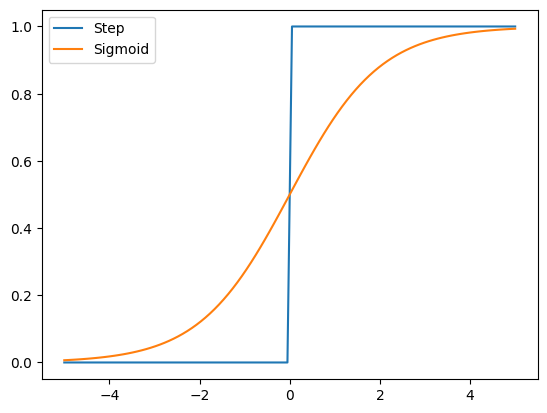

In [ ]:
import matplotlib.pyplot as plt

x = np.linspace(-5,5,100)

step_values = [step(i) for i in x]
sigmoid_values = 1/(1+np.exp(-x))

plt.plot(x, step_values, label="Step")
plt.plot(x, sigmoid_values, label="Sigmoid")
plt.legend()
plt.show()

5.Perceptron Learning Algorithm (Movie Dataset)

In [ ]:
# Movie dataset
X = np.array([
    [1,1,1,0.9],
    [1,0,1,0.8],
    [0,1,0,0.4],
    [0,0,0,0.2]
])

y = np.array([1,1,0,0])

w = np.zeros(4)
b = 0
lr = 0.1

for epoch in range(10):
    for i in range(len(X)):
        y_pred = step(np.dot(X[i], w) + b)
        error = y[i] - y_pred
        w += lr * error * X[i]
        b += lr * error

print("Final Weights:", w)
print("Final Bias:", b)

Final Weights: [ 0.1  -0.1   0.1   0.01]
Final Bias: -0.1


# WEEK 3

1.Implement MLP by Varying Learning Rate and Plot Loss vs Learning Rate

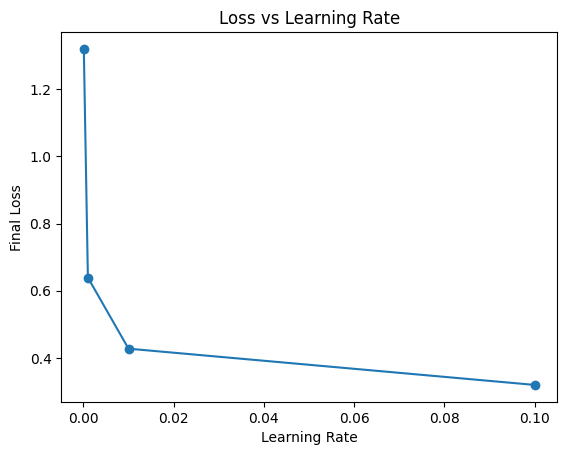

In [ ]:
# Import required libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


# Step 1: Load Fashion MNIST Dataset

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize data
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten images (28x28 → 784)
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# Step 2: Define Learning Rates

learning_rates = [0.1, 0.01, 0.001, 0.0001]
final_losses = []

# Step 3: Train Model for Each LR

for lr in learning_rates:

    model = tf.keras.Sequential([
        tf.keras.Input(shape=(784,)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    optimizer = tf.keras.optimizers.SGD(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy'
    )

    history = model.fit(
        X_train, y_train,
        epochs=5,
        verbose=0
    )

    final_loss = history.history['loss'][-1]
    final_losses.append(final_loss)

# Step 4: Plot Graph

plt.plot(learning_rates, final_losses, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss")
plt.title("Loss vs Learning Rate")
plt.show()

2.Implement MLP using Gradient Descent

In [ ]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(784,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6814 - loss: 1.0136 - val_accuracy: 0.8088 - val_loss: 0.5617
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8220 - loss: 0.5260 - val_accuracy: 0.8284 - val_loss: 0.5020
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8355 - loss: 0.4794 - val_accuracy: 0.8341 - val_loss: 0.4800
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8442 - loss: 0.4498 - val_accuracy: 0.8405 - val_loss: 0.4602
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8519 - loss: 0.4311 - val_accuracy: 0.8428 - val_loss: 0.4460
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8571 - loss: 0.4155 - val_accuracy: 0.8412 - val_loss: 0.4486
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8601 - loss: 0.4032 - val_accuracy: 0.8451 - val_loss: 0.4370
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8626 - loss: 0.3931 - 

3.Perceptron on IRIS Dataset

In [ ]:
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Try different learning rates
for lr in [1.0, 0.1, 0.01]:

    model = Perceptron(
        eta0=lr,
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("Learning Rate:", lr)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print()

Learning Rate: 1.0
Accuracy: 0.6333333333333333

Learning Rate: 0.1
Accuracy: 0.6333333333333333

Learning Rate: 0.01
Accuracy: 0.6



4.MLP on Dataset (Parameter Exploration)

In [ ]:
import tensorflow as tf
import numpy as np

# Load Fashion MNIST Dataset (re-loading to ensure correct data is used)
(X_train, y_train), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize data
X_train = X_train / 255.0

# Flatten images (28x28 → 784)
X_train = X_train.reshape(-1, 784)

model = tf.keras.Sequential([
    tf.keras.Input(shape=(784,)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7917 - loss: 0.5954
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8639 - loss: 0.3693
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8800 - loss: 0.3262
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8848 - loss: 0.3063
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8958 - loss: 0.2793
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8998 - loss: 0.2684
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9068 - loss: 0.2462
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9081 - loss: 0.2407
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9113 - loss: 0.2333
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9156 - loss: 0.2230


5.MLP for MNIST Handwritten Digits

In [ ]:
# Load MNIST
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

model = tf.keras.Sequential([
    tf.keras.Input(shape=(784,)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=10)

loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8916 - loss: 0.3574
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9738 - loss: 0.0865
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9818 - loss: 0.0560
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9866 - loss: 0.0409
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9910 - loss: 0.0280
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9910 - loss: 0.0269
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9929 - loss: 0.0220
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9940 - loss: 0.0189
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9954 - loss: 0.0133
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9955 - loss: 0.0144
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9743 - loss: 0.1211
Test Accuracy: 0.9793000221252441


using fashion mnist dataset

In [ ]:
#COMMON DATASET (Fashion MNIST)
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten for MLP
x_train_flat = x_train.reshape(-1, 28*28)
x_test_flat = x_test.reshape(-1, 28*28)

# One-hot
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


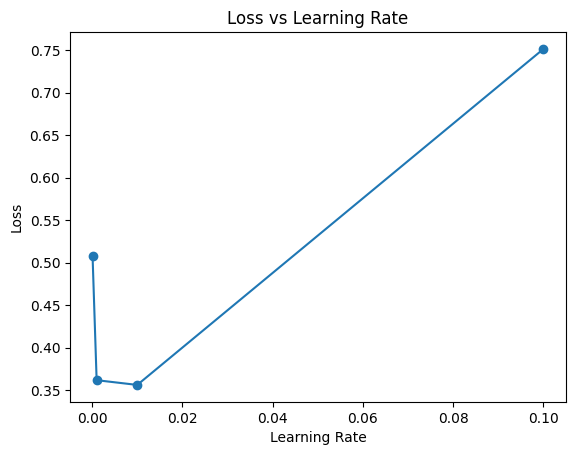

In [ ]:
#Q9. MLP – Vary Learning Rate + Plot

learning_rates = [0.0001, 0.001, 0.01, 0.1]
losses = []

for lr in learning_rates:
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation='relu', input_shape=(784,)),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(x_train_flat, y_train_cat,
                        epochs=3, batch_size=128, verbose=0)

    losses.append(history.history['loss'][-1])

# Plot
plt.plot(learning_rates, losses, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Loss vs Learning Rate")
plt.show()

'''
Observation:
Very low LR → slow learning
Very high LR → unstable training
Optimal LR ≈ 0.001–0.01
''''

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6550 - loss: 1.0871
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7700 - loss: 0.6945
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7994 - loss: 0.6076
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8137 - loss: 0.5605
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8222 - loss: 0.5300
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8292 - loss: 0.5083
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8331 - loss: 0.4919
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8369 - loss: 0.4787
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8406 - loss: 0.4682
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8433 - loss: 0.4587


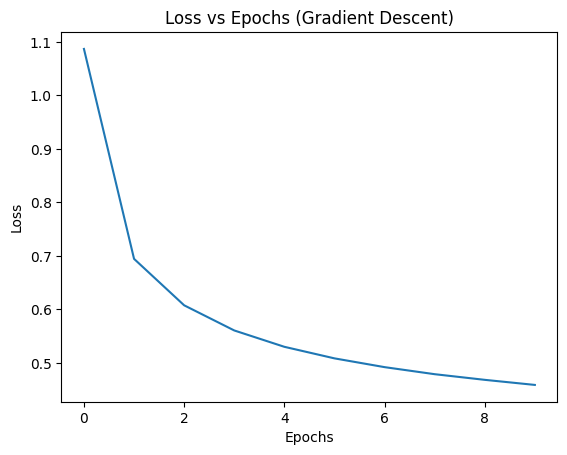

In [ ]:
#Q10. MLP using Gradient Descent
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dense(10, activation='softmax')
])

# SGD = Gradient Descent
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train_flat, y_train_cat,
                    epochs=10, batch_size=128)

# Plot convergence
plt.plot(history.history['loss'])
plt.title("Loss vs Epochs (Gradient Descent)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

'''
Observation:
Loss decreases gradually → convergence
SGD is slower than Adam but stable
'''

In [ ]:
#Q11. Perceptron (Using Fashion MNIST instead of IRIS)

from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

# Use subset for speed
x_train_small = x_train_flat[:10000]
y_train_small = y_train[:10000]

learning_rates = [0.0001, 0.001, 0.01]
accuracies = []

for lr in learning_rates:
    clf = Perceptron(eta0=lr, max_iter=1000)
    clf.fit(x_train_small, y_train_small)

    preds = clf.predict(x_test_flat)
    acc = accuracy_score(y_test, preds)
    accuracies.append(acc)

print("Accuracies:", accuracies)

'''
Observation:
Higher LR → faster learning but may overshoot
Moderate LR gives better accuracy
'''

Accuracies: [0.7508, 0.7322, 0.7741]


'\nObservation:\nHigher LR → faster learning but may overshoot\nModerate LR gives better accuracy\n'

In [ ]:
#Q12. MLP – Parameter Tuning

configs = [
    {"lr":0.001, "epochs":5},
    {"lr":0.01, "epochs":5},
    {"lr":0.001, "epochs":10}
]

for config in configs:
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation='relu', input_shape=(784,)),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=config["lr"]),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(x_train_flat, y_train_cat,
                        epochs=config["epochs"], verbose=0)

    print(f"LR={config['lr']}, Epochs={config['epochs']}, Acc={history.history['accuracy'][-1]}")

'''
Observation:
More epochs → better accuracy
LR = 0.001 performs best
Too high LR reduces stability
'''

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


LR=0.001, Epochs=5, Acc=0.8907666802406311
LR=0.01, Epochs=5, Acc=0.8591833114624023
LR=0.001, Epochs=10, Acc=0.9111166596412659


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8202 - loss: 0.5138 - val_accuracy: 0.8462 - val_loss: 0.4347
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8669 - loss: 0.3663 - val_accuracy: 0.8622 - val_loss: 0.3819
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8798 - loss: 0.3294 - val_accuracy: 0.8728 - val_loss: 0.3543
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8867 - loss: 0.3068 - val_accuracy: 0.8711 - val_loss: 0.3599
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8933 - loss: 0.2875 - val_accuracy: 0.8745 - val_loss: 0.3368
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8982 - loss: 0.2734 - val_accuracy: 0.8791 - val_loss: 0.3268
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9048 - loss: 0.2586 - val_accuracy: 0.8760 - val_loss: 0.3383
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9070 - loss: 0.2476 - val_accuracy: 0.

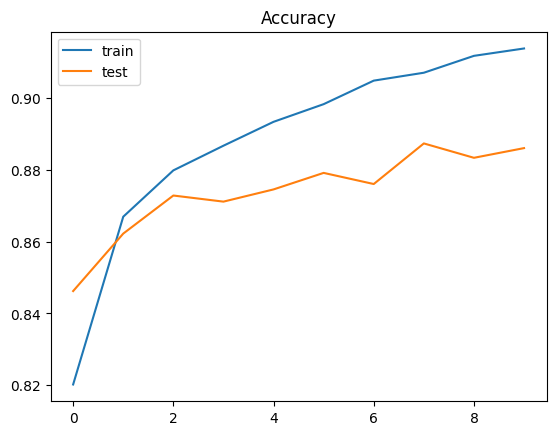

'\nObservation:\nDeep MLP improves performance\nValidation accuracy shows generalization\nMore layers → better feature learning\n'

In [ ]:
#Q13. MLP for Fashion MNIST (Final Model)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train_flat, y_train_cat,
                    epochs=10, batch_size=128,
                    validation_data=(x_test_flat, y_test_cat))

# Accuracy Plot
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.legend()
plt.title("Accuracy")
plt.show()

'''
Observation:
Deep MLP improves performance
Validation accuracy shows generalization
More layers → better feature learning
'''


# WEEK 4

Implement MLP Using Different Types of Gradient Descent for XOR

In [ ]:
#XOR DATASET
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# XOR dataset
X = np.array(
    [
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1]
    ]
)

y = np.array([0, 1, 1, 0])

# Function to train model with given optimizer
def train_optimizer(optimizer, name):

    model = tf.keras.Sequential(
        [
            tf.keras.Input(shape=(2,)),
            tf.keras.layers.Dense(8, activation='relu'),
            tf.keras.layers.Dense(1, activation='sigmoid'),
        ]
    )

    model.compile(optimizer=optimizer, loss='binary_crossentropy')

    history = model.fit(X, y, epochs=300, verbose=0)

    final_loss = history.history['loss'][-1]
    print(name, "Final Loss:", final_loss)

    return final_loss

# Train with All Optimizers
losses = {}

# Batch GD (SGD with full batch)
losses["BGD"] = train_optimizer(
    tf.keras.optimizers.SGD(learning_rate=0.1), "Batch GD"
)

# SGD (batch size 1)
losses["SGD"] = train_optimizer(
    tf.keras.optimizers.SGD(learning_rate=0.1), "SGD"
)

# Momentum
losses["Momentum"] = train_optimizer(
    tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9), "Momentum"
)

# Nesterov
losses["Nesterov"] = train_optimizer(
    tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9, nesterov=True),
    "Nesterov",
)

# Adagrad
losses["Adagrad"] = train_optimizer(
    tf.keras.optimizers.Adagrad(learning_rate=0.1), "Adagrad"
)

# RMSProp
losses["RMSProp"] = train_optimizer(
    tf.keras.optimizers.RMSprop(learning_rate=0.01), "RMSProp"
)

# Adadelta
losses["Adadelta"] = train_optimizer(
    tf.keras.optimizers.Adadelta(), "Adadelta"
)

# Adam
losses["Adam"] = train_optimizer(
    tf.keras.optimizers.Adam(learning_rate=0.01), "Adam"
)
# Test on Real Dataset (Fashion MNIST)
# Load dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

X_train = X_train / 255.0
X_train = X_train.reshape(-1, 784)

def train_fashion(optimizer, name):

    model = tf.keras.Sequential(
        [
            tf.keras.Input(shape=(784,)),
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dense(10, activation='softmax'),
        ]
    )

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )

    history = model.fit(X_train, y_train, epochs=5, verbose=0)

    acc = history.history['accuracy'][-1]
    print(name, "Accuracy:", acc)

    return acc


#Train with Major Optimizers
train_fashion(tf.keras.optimizers.SGD(0.01), "SGD")
train_fashion(tf.keras.optimizers.SGD(0.01, momentum=0.9), "Momentum")
train_fashion(tf.keras.optimizers.RMSprop(0.001), "RMSProp")
train_fashion(tf.keras.optimizers.Adam(0.001), "Adam")

Batch GD Final Loss: 0.15763604640960693
SGD Final Loss: 0.18381839990615845
Momentum Final Loss: 0.006015644874423742
Nesterov Final Loss: 0.007357585709542036
Adagrad Final Loss: 0.08654376119375229
RMSProp Final Loss: 0.013676752336323261
Adadelta Final Loss: 0.6983456015586853
Adam Final Loss: 0.02074703946709633
SGD Accuracy: 0.8538166880607605
Momentum Accuracy: 0.8820833563804626
RMSProp Accuracy: 0.8905166387557983
Adam Accuracy: 0.8922833204269409


0.8922833204269409

In [ ]:
#YOUR OWN DATASET (FASHION MNIST)
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

# Load data
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Model
def create_model():
    return tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation='relu', input_shape=(784,)),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

# Optimizers (FUNCTION → IMPORTANT)
def get_optimizers():
    return {
        "SGD": tf.keras.optimizers.SGD(learning_rate=0.01),
        "Momentum": tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
        "Nesterov": tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
        "Adagrad": tf.keras.optimizers.Adagrad(learning_rate=0.01),
        "RMSProp": tf.keras.optimizers.RMSprop(learning_rate=0.001),
        "Adadelta": tf.keras.optimizers.Adadelta(),
        "Adam": tf.keras.optimizers.Adam(learning_rate=0.001)
    }

# Training
results_fashion = {}

for name, opt in get_optimizers().items():
    print(f"Training with {name}")

    model = create_model()

    model.compile(optimizer=opt,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(x_train, y_train,
                        epochs=3,
                        batch_size=128,
                        verbose=1)

    results_fashion[name] = (
        history.history['accuracy'][-1],
        history.history['loss'][-1]
    )

print("\nResults:", results_fashion)

Training with SGD
Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6671 - loss: 1.0968
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7836 - loss: 0.6820
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8076 - loss: 0.5969
Training with Momentum
Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7872 - loss: 0.6282
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8400 - loss: 0.4585
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8534 - loss: 0.4219
Training with Nesterov
Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7871 - loss: 0.6238
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8437 - loss: 0.4507
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8561 - loss: 0.4135
Training with Adagrad
Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7499 - loss: 0.7921
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0

In [ ]:
#PLOT COMPARISON

names = list(results_fashion.keys())
acc = [v[0] for v in results_fashion.values()]

plt.bar(names, acc)
plt.xticks(rotation=45)
plt.title("Optimizer Comparison")
plt.show()

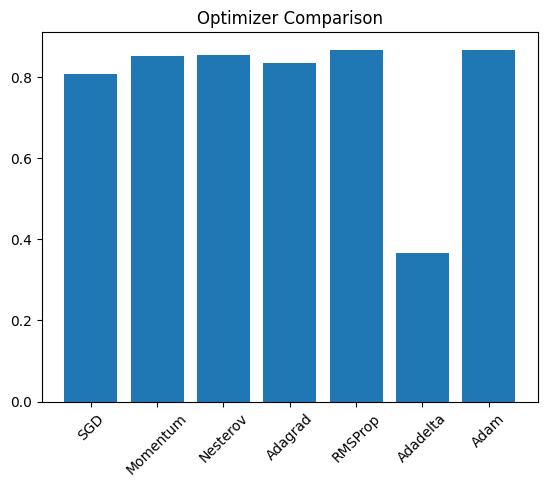

In [ ]:
#PLOT COMPARISON

names = list(results_fashion.keys())
acc = [v[0] for v in results_fashion.values()]

plt.bar(names, acc)
plt.xticks(rotation=45)
plt.title("Optimizer Comparison")
plt.show()

# WEEK 5

Implement MLP using Different Regularization Techniques

In [ ]:

Base Model (Without Regularization)
import tensorflow as tf
import numpy as np

# Load dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# Base Model
def base_model():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(784,)),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = base_model()
model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7869 - loss: 0.6066 - val_accuracy: 0.8559 - val_loss: 0.3927
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8636 - loss: 0.3725 - val_accuracy: 0.8657 - val_loss: 0.3662
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8775 - loss: 0.3324 - val_accuracy: 0.8697 - val_loss: 0.3638
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8879 - loss: 0.3045 - val_accuracy: 0.8744 - val_loss: 0.3473
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8914 - loss: 0.2862 - val_accuracy: 0.8768 - val_loss: 0.3475
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8986 - loss: 0.2655 - val_accuracy: 0.8775 - val_loss: 0.3319
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9045 - loss: 0.2512 - val_accuracy: 0.8851 - val_loss: 0.3370
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9076 - loss: 0.2416 - 

1. L2 Regularization

In [ ]:
from tensorflow.keras import regularizers

def l2_model():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(784,)),
        tf.keras.layers.Dense(256, activation='relu',
                              kernel_regularizer=regularizers.l2(0.001)),
        tf.keras.layers.Dense(128, activation='relu',
                              kernel_regularizer=regularizers.l2(0.001)),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = l2_model()
model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7806 - loss: 0.9367 - val_accuracy: 0.8333 - val_loss: 0.5963
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8502 - loss: 0.5470 - val_accuracy: 0.8358 - val_loss: 0.5554
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8597 - loss: 0.4938 - val_accuracy: 0.8596 - val_loss: 0.4833
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8652 - loss: 0.4580 - val_accuracy: 0.8615 - val_loss: 0.4701
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8696 - loss: 0.4388 - val_accuracy: 0.8589 - val_loss: 0.4754
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8743 - loss: 0.4261 - val_accuracy: 0.8595 - val_loss: 0.4628
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8727 - loss: 0.4201 - val_accuracy: 0.8548 - val_loss: 0.4815
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8774 - loss: 0.4111 - 

2.Dropout

In [ ]:
def dropout_model():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(784,)),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = dropout_model()
model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6717 - loss: 0.9112 - val_accuracy: 0.8318 - val_loss: 0.4676
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8104 - loss: 0.5232 - val_accuracy: 0.8405 - val_loss: 0.4257
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8259 - loss: 0.4828 - val_accuracy: 0.8477 - val_loss: 0.4128
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8373 - loss: 0.4457 - val_accuracy: 0.8515 - val_loss: 0.3978
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8438 - loss: 0.4315 - val_accuracy: 0.8553 - val_loss: 0.3967
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8460 - loss: 0.4181 - val_accuracy: 0.8598 - val_loss: 0.3842
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8507 - loss: 0.4172 - val_accuracy: 0.8615 - val_loss: 0.3792
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8516 - loss: 0.4065 - 

3.Early Stopping

In [ ]:
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

model = base_model()

model.fit(X_train, y_train,
          epochs=50,
          validation_data=(X_test, y_test),
          callbacks=[callback])

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7857 - loss: 0.5984 - val_accuracy: 0.8451 - val_loss: 0.4200
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8681 - loss: 0.3593 - val_accuracy: 0.8608 - val_loss: 0.3849
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8815 - loss: 0.3220 - val_accuracy: 0.8691 - val_loss: 0.3703
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8875 - loss: 0.3035 - val_accuracy: 0.8799 - val_loss: 0.3364
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8929 - loss: 0.2858 - val_accuracy: 0.8692 - val_loss: 0.3520
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9010 - loss: 0.2635 - val_accuracy: 0.8752 - val_loss: 0.3418
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9058 - loss: 0.2515 - val_accuracy: 0.8808 - val_loss: 0.3390


4.Adding Noise to Inputs

In [ ]:
noise_factor = 0.2
X_train_noisy = X_train + noise_factor * np.random.normal(size=X_train.shape)

model = base_model()
model.fit(X_train_noisy, y_train,
          epochs=10,
          validation_data=(X_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7675 - loss: 0.6436 - val_accuracy: 0.8527 - val_loss: 0.4086
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8575 - loss: 0.3818 - val_accuracy: 0.8567 - val_loss: 0.3903
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8787 - loss: 0.3270 - val_accuracy: 0.8470 - val_loss: 0.4181
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8937 - loss: 0.2878 - val_accuracy: 0.8668 - val_loss: 0.3675
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9034 - loss: 0.2542 - val_accuracy: 0.8783 - val_loss: 0.3611
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9146 - loss: 0.2241 - val_accuracy: 0.8633 - val_loss: 0.4372
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9254 - loss: 0.2011 - val_accuracy: 0.8732 - val_loss: 0.3832
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9320 - loss: 0.1805 - 

5.Dataset Augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
import numpy as np

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

X_train_images = X_train.reshape(-1,28,28,1)

datagen.fit(X_train_images)

# Define a new model compatible with 4D image input (28, 28, 1)
def augmented_model():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(28, 28, 1)), # Accept 4D image input
        tf.keras.layers.Flatten(),         # Flatten the images to 784 features
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = augmented_model() # Use the new model

# Reshape X_test for validation data as well
X_test_images = X_test.reshape(-1,28,28,1)

model.fit(datagen.flow(X_train_images, y_train, batch_size=64),
          epochs=10,
          validation_data=(X_test_images, y_test))

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 22ms/step - accuracy: 0.6555 - loss: 0.9179 - val_accuracy: 0.7895 - val_loss: 0.5619
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.7658 - loss: 0.6218 - val_accuracy: 0.8082 - val_loss: 0.5142
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.7831 - loss: 0.5690 - val_accuracy: 0.8206 - val_loss: 0.4760
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.7956 - loss: 0.5409 - val_accuracy: 0.8209 - val_loss: 0.4700
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.8034 - loss: 0.5151 - val_accuracy: 0.8157 - val_loss: 0.4683
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.8059 - loss: 0.5027 - val_accuracy: 0.8360 - val_loss: 0.4336
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.8146 - loss: 0.4864 - val_accuracy: 0.8278 - val_loss: 0.4498
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.8142 - loss: 0.4818 - val_accurac

6.Ensemble Methods

In [ ]:
models = []

for i in range(3):
    m = base_model()
    m.fit(X_train, y_train, epochs=5, verbose=0)
    models.append(m)

# Average predictions
preds = [m.predict(X_test) for m in models]
avg_pred = np.mean(preds, axis=0)

final_accuracy = np.mean(np.argmax(avg_pred, axis=1) == y_test)

print("Ensemble Accuracy:", final_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Ensemble Accuracy: 0.8884


7.Parameter Sharing and Tying

# WEEK 6

Implement CNN on MNIST Dataset


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import models

# Step 1: Load MNIST dataset

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape to include channel dimension
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

# Step 2: Define CNN Model

model = models.Sequential([

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),

    layers.Dense(10,activation='softmax')
])

# Step 3: Compile Model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Step 4: Train Model

model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test,y_test)
)

# Step 5: Evaluate Model

loss,accuracy = model.evaluate(X_test,y_test)

print("Test Accuracy:",accuracy)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9611 - loss: 0.1280 - val_accuracy: 0.9877 - val_loss: 0.0392
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9867 - loss: 0.0423 - val_accuracy: 0.9876 - val_loss: 0.0361
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9910 - loss: 0.0293 - val_accuracy: 0.9876 - val_loss: 0.0338
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9932 - loss: 0.0208 - val_accuracy: 0.9885 - val_loss: 0.0367
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9947 - loss: 0.0161 - val_accuracy: 0.9885 - val_loss: 0.0387
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9885 - loss: 0.0387
Test Accuracy: 0.9884999990463257


Apply CNN on Own Dataset

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import models

# Load dataset

(X_train,y_train),(X_test,y_test) = tf.keras.datasets.fashion_mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

# CNN Model

model = models.Sequential([

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10,activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model

model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test,y_test)
)

loss,acc = model.evaluate(X_test,y_test)

print("Accuracy:",acc)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.7989 - loss: 0.5567 - val_accuracy: 0.8642 - val_loss: 0.3683
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8731 - loss: 0.3541 - val_accuracy: 0.8844 - val_loss: 0.3112
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8908 - loss: 0.3037 - val_accuracy: 0.8972 - val_loss: 0.2775
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9024 - loss: 0.2684 - val_accuracy: 0.9014 - val_loss: 0.2664
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9106 - loss: 0.2471 - val_accuracy: 0.9031 - val_loss: 0.2660
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9182 - loss: 0.2244 - val_accuracy: 0.9076 - val_loss: 0.2577
Epoch 7/10
1875/1875 ━━━━━━━━━━



# WEEK 7

Implement AlexNet

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# AlexNet simplified
model = models.Sequential([

    tf.keras.Input(shape=(224,224,3)),

    layers.Conv2D(96,(11,11),strides=4,activation='relu'),
    layers.MaxPooling2D((3,3),strides=2),

    layers.Conv2D(256,(5,5),activation='relu',padding='same'),
    layers.MaxPooling2D((3,3),strides=2),

    layers.Conv2D(384,(3,3),activation='relu',padding='same'),
    layers.Conv2D(384,(3,3),activation='relu',padding='same'),
    layers.Conv2D(256,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D((3,3),strides=2),

    layers.Flatten(),

    layers.Dense(4096,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(4096,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10,activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,787,978 (178.48 MB)

 Trainable params: 46,787,978 (178.48 MB)

 Non-trainable params: 0 (0.00 B)

Implement ZFNet

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([

    tf.keras.Input(shape=(224,224,3)),

    layers.Conv2D(96,(7,7),strides=2,activation='relu'),
    layers.MaxPooling2D((3,3),strides=2),

    layers.Conv2D(256,(5,5),activation='relu',padding='same'),
    layers.MaxPooling2D((3,3),strides=2),

    layers.Conv2D(384,(3,3),activation='relu',padding='same'),
    layers.Conv2D(384,(3,3),activation='relu',padding='same'),
    layers.Conv2D(256,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D((3,3),strides=2),

    layers.Flatten(),

    layers.Dense(4096,activation='relu'),
    layers.Dense(4096,activation='relu'),

    layers.Dense(10,activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 109, 109, 96)   │        14,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 54, 54, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 54, 54, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 26, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   150,999,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 171,547,786 (654.40 MB)

 Trainable params: 171,547,786 (654.40 MB)

 Non-trainable params: 0 (0.00 B)

Implement VGG16

In [ ]:
model = models.Sequential([

    tf.keras.Input(shape=(224,224,3)),

    # Block 1
    layers.Conv2D(64,(3,3),activation='relu',padding='same'),
    layers.Conv2D(64,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D((2,2)),

    # Block 2
    layers.Conv2D(128,(3,3),activation='relu',padding='same'),
    layers.Conv2D(128,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D((2,2)),

    # Block 3
    layers.Conv2D(256,(3,3),activation='relu',padding='same'),
    layers.Conv2D(256,(3,3),activation='relu',padding='same'),
    layers.Conv2D(256,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D((2,2)),

    # Block 4
    layers.Conv2D(512,(3,3),activation='relu',padding='same'),
    layers.Conv2D(512,(3,3),activation='relu',padding='same'),
    layers.Conv2D(512,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D((2,2)),

    # Block 5
    layers.Conv2D(512,(3,3),activation='relu',padding='same'),
    layers.Conv2D(512,(3,3),activation='relu',padding='same'),
    layers.Conv2D(512,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(4096,activation='relu'),
    layers.Dense(4096,activation='relu'),

    layers.Dense(10,activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,301,514 (512.32 MB)

 Trainable params: 134,301,514 (512.32 MB)

 Non-trainable params: 0 (0.00 B)

# WEEK 8


In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

# 2. Define the Encoder and Decoder
input_dim =      784  # 28x28 images
encoding_dim = 78  # Compressed representation

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# 3. Create the Autoencoder Model
autoencoder = Model(input_layer, decoded)

# 4. Compile the Model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Train the Model
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))

# 6. Test the Model
decoded_imgs = autoencoder.predict(x_test)

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

Epoch 1/50


ValueError: Input 0 with name 'input_layer_11' of layer 'functional_11' is incompatible with the layer: expected shape=(None, 1784), found shape=(None, 784)

# week 8

In [ ]:
#1. IMPORT + DATA
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# VERY small dataset
x_train = x_train[:3000]
y_train = y_train[:3000]

x_test = x_test[:1000]
y_test = y_test[:1000]

# normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# reshape
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

# resize small
x_train = tf.image.resize(x_train, (64,64))
x_test = tf.image.resize(x_test, (64,64))

# convert to RGB
x_train = tf.image.grayscale_to_rgb(x_train)
x_test = tf.image.grayscale_to_rgb(x_test)

y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

In [ ]:
#2. INCEPTION (GOOGLENET)
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

# Load
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

#STEP 1: ADD CHANNEL FIRST
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

#STEP 2: RESIZE
x_train = tf.image.resize(x_train, (96,96))
x_test = tf.image.resize(x_test, (96,96))

#STEP 3: CONVERT TO RGB
x_train = tf.image.grayscale_to_rgb(x_train)
x_test = tf.image.grayscale_to_rgb(x_test)

# Labels
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

In [ ]:
#2. LIGHT MODEL (MobileNet)

from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(64,64,3)
)

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=2, batch_size=32)

/tmp/ipykernel_977/1142743831.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/2
94/94 ━━━━━━━━━━━━━━━━━━━━ 34s 153ms/step - accuracy: 0.6073 - loss: 1.1736
Epoch 2/2
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.7883 - loss: 0.6144


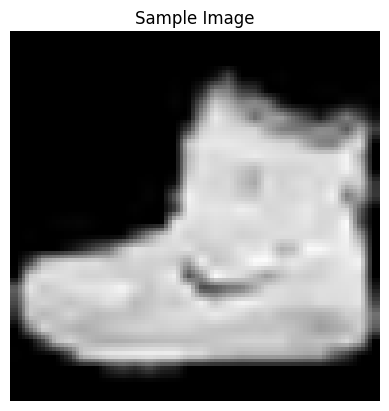

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0].numpy().reshape(96,96,3))
plt.title("Sample Image")
plt.axis('off')
plt.show()

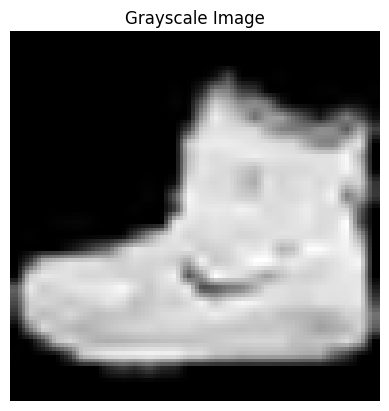

In [ ]:
plt.imshow(x_train[0].numpy().mean(axis=-1), cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

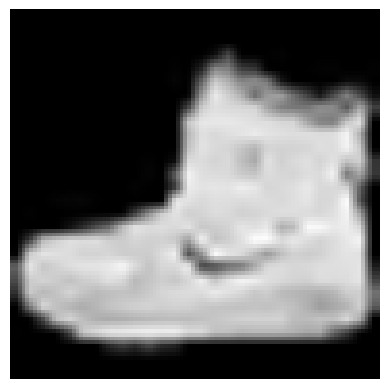

In [ ]:
plt.imshow(x_train[0].numpy().reshape(96,96,3))
plt.axis('off')
plt.show()

# WEEK - 9

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0162 - val_loss: 0.0091
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0077 - val_loss: 0.0064
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0057 - val_loss: 0.0051
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0047 - val_loss: 0.0044
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0041 - val_loss: 0.0040
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step


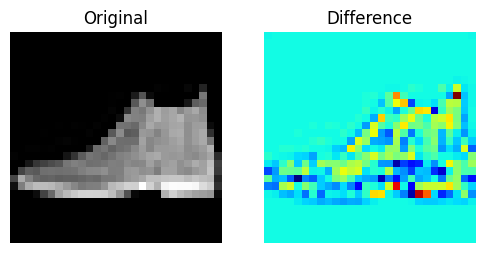

In [ ]:
#IMPORT DATA

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

# Load dataset
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape for CNN
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)



#AUTOENCODER MODEL (CNN)
model = tf.keras.Sequential([

    tf.keras.Input(shape=(28,28,1)),

    #Encoder
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',padding='same'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu',padding='same'),
    tf.keras.layers.MaxPooling2D(2,2),

    #Decoder
    tf.keras.layers.Conv2D(64,(3,3),activation='relu',padding='same'),
    tf.keras.layers.UpSampling2D(2),

    tf.keras.layers.Conv2D(32,(3,3),activation='relu',padding='same'),
    tf.keras.layers.UpSampling2D(2),

    tf.keras.layers.Conv2D(1,(3,3),activation='sigmoid',padding='same')
])

#COMPILE
model.compile(
    optimizer='adam',
    loss='mse'
)

#TRAIN

history = model.fit(
    x_train, x_train,
    epochs=5,
    batch_size=128,
    validation_data=(x_test, x_test)
)

#RECONSTRUCTION
# Take one sample
original = x_test[0:1]

# Reconstruct
reconstructed = model.predict(original)

#VISUALIZE (IMPORTANT FOR MARKS)
plt.figure(figsize=(6,3))

# Original
plt.subplot(1,2,1)
plt.imshow(original[0].reshape(28,28), cmap='gray')
plt.title("Original")
plt.axis('off')

# Reconstructed
plt.subplot(1,2,2)
diff = original - reconstructed

plt.imshow(diff[0].reshape(28,28), cmap='jet')
plt.title("Difference")
plt.axis('off')
plt.show()

In [ ]:
import numpy as np

noise = np.random.normal(0, 0.5, x_train.shape)

x_train_noisy = x_train + noise
x_test_noisy = x_test + noise[:len(x_test)]

# clip values
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

In [ ]:
history = model.fit(
    x_train_noisy, x_train,
    epochs=5,
    batch_size=128,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0201 - val_loss: 0.0174
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0166 - val_loss: 0.0164
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0160 - val_loss: 0.0159
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0156 - val_loss: 0.0156
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0153 - val_loss: 0.0153


In [ ]:
original = x_test[0:1]
noisy = x_test_noisy[0:1]

reconstructed = model.predict(noisy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


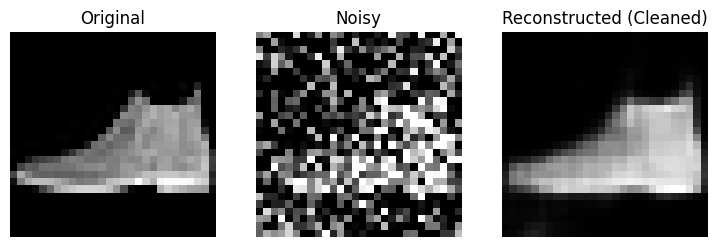

In [ ]:
plt.figure(figsize=(9,3))

# original
plt.subplot(1,3,1)
plt.imshow(original[0].reshape(28,28), cmap='gray')
plt.title("Original")
plt.axis('off')

# noisy
plt.subplot(1,3,2)
plt.imshow(noisy[0].reshape(28,28), cmap='gray')
plt.title("Noisy")
plt.axis('off')

# reconstructed
plt.subplot(1,3,3)
plt.imshow(reconstructed[0].reshape(28,28), cmap='gray')
plt.title("Reconstructed (Cleaned)")
plt.axis('off')

plt.show()

# Observation:

- Basic autoencoder reconstructs input without improving quality.
- Denoising autoencoder removes noise from corrupted images.
- The reconstructed image is clearer than the noisy input.

# Conclusion:
Denoising autoencoders can improve image quality by learning noise patterns.